# International Student Text Processing

## Introduction

This notebook analyzes a corpus of 150 Reddit posts about international student experiences (r/internationalstudents and related threads), totaling more than 24,000 words. The central research question is: **What themes are most commonly discussed by international students in online communities?** Understanding these themes has direct real-world value — universities, international student offices, and mental health services can use findings like these to prioritize support programs and identify gaps in resources.

The pipeline processes raw Reddit text using a custom `TextProcessing` class, then applies two independent topic analysis methods: **LDA** (Latent Dirichlet Allocation) for interpretable keyword-based topics, and **BERT** embeddings with K-Means clustering for semantically rich groupings.

## Data Loading & Preprocessing

The corpus is loaded from `InternationalStudent.csv`, which contains a single `Text` column of Reddit posts. The `TextProcessing` class handles the full pipeline: contraction expansion, lowercasing, HTML/URL removal, tokenization, spell correction via `aspell.txt`, stopword removal (including a custom Reddit-specific set), number removal, and Porter stemming.

**Changes made to the base `TextProcessing` class:**
- Added a `process_dataframe()` method to apply `set_text()` across an entire DataFrame column.
- Extended the default stopword list with Reddit-specific filler words (e.g., `'feel'`, `'like'`, `'reddit'`).
- Added a `vectorize()` method using `TfidfVectorizer` from scikit-learn.

## Exploratory Analysis

Before modeling, we examine basic corpus statistics: document count, word counts, and the most frequent terms after preprocessing.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from InternationalStudentTextProcessing import TextProcessing

df = pd.read_csv("InternationalStudent.csv")
print(f"Total documents: {len(df)}")

# Document length distribution (words)
df['word_count'] = df['Text'].dropna().apply(lambda x: len(str(x).split()))
print(f"Total words: {df['word_count'].sum():,}")
print(f"Avg words per post: {df['word_count'].mean():.1f}")
print(f"Min: {df['word_count'].min()}  Max: {df['word_count'].max()}")

# Plot document length distribution
plt.figure(figsize=(8, 4))
plt.hist(df['word_count'].dropna(), bins=30, edgecolor='black')
plt.xlabel("Words per Post")
plt.ylabel("Number of Posts")
plt.title("Document Length Distribution")
plt.tight_layout()
plt.show()

# Top 20 words after preprocessing
tp_eda = TextProcessing(lemmatization=False)
all_tokens = []
for text in df['Text'].dropna():
    tokens = tp_eda.set_text(text)
    if isinstance(tokens, list):
        all_tokens.extend(tokens)

word_freq = Counter(all_tokens).most_common(20)
words, counts = zip(*word_freq)

plt.figure(figsize=(10, 4))
plt.bar(words, counts)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.title("Top 20 Words After Preprocessing")
plt.tight_layout()
plt.show()

print("Top 20 words:", word_freq)

## Vectorization (TF-IDF)

Before topic modeling, we convert the preprocessed token lists into a TF-IDF matrix using the `vectorize()` method built into `TextProcessing`. TF-IDF weights each term by how distinctive it is across the corpus — common words across all posts receive lower weight, while terms specific to a subset of posts rank higher. This numerical representation is suitable for downstream tasks such as classification or similarity search.

In [ ]:
# Preprocess the full dataframe first (reused by LDA and BERT sections below)
tp = TextProcessing(
    lemmatization=False,
    additional_stop_words={
        'feel', 'like', 'know', 'want', 'get', 'go', 'would', 'could',
        'one', 'even', 'still', 'really', 'also', 'much', 'many',
        'thing', 'things', 'people', 'anyone', 'someone', 'make',
        'see', 'say', 'said', 'tell', 'think', 'time', 'year',
        'years', 'post', 'reddit', 'im', 'ive', 'id', 'ill', 'dont',
        'doesnt', 'didnt', 'cant', 'couldnt', 'wouldnt', 'shouldnt',
        'isnt', 'arent', 'wasnt', 'werent', 'thats', 'theres', 'whats',
        'youre', 'theyre', 'not', 'us', 'good', 'bad', 'lot', 'way',
        'help', 'need', 'going', 'got', 'back', 'right', 'actually'
    }
)

processed_df = tp.process_dataframe(df, text_column='Text')

# Build TF-IDF matrix using the vectorize() method
tfidf_texts = processed_df['processed_text_string'].dropna().tolist()
tfidf_matrix, tfidf_vectorizer = tp.vectorize(tfidf_texts)

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"  → {tfidf_matrix.shape[0]} documents × {tfidf_matrix.shape[1]} features")

# Show top TF-IDF terms for the first document
import numpy as np
feature_names = tfidf_vectorizer.get_feature_names_out()
first_doc = tfidf_matrix[0].toarray().flatten()
top_indices = np.argsort(first_doc)[::-1][:10]
print("\nTop TF-IDF terms for post #1:")
for idx in top_indices:
    if first_doc[idx] > 0:
        print(f"  {feature_names[idx]}: {first_doc[idx]:.4f}")

# A. Latent Dirichlet Allocation (LDA)
- Use LDA to extract topics from your corpus.

- Determine the optimal number of topics using coherence scores.

- Visualize the results.

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
from InternationalStudentTextProcessing import TextProcessing

In [92]:
df = pd.read_csv("InternationalStudent.csv")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (150, 1)
Columns: ['Text']


,Text
0,International students in the U.S. – what’s yo...
1,Brutal truths international students learn the...
2,Life of an international student\n\nreddit -> ...
3,In what world are international students livin...
4,International Student Experience\n\nI’m an int...


In [121]:
tp = TextProcessing(
    lemmatization=False,
    additional_stop_words = {
    "feel", "like", "know", "want", "get", "go", "would", "could",
    "one", "even", "still", "really", "also", "much", "many",
    "thing", "things", "people", "anyone", "someone", "make",
    "see", "say", "said", "tell", "think", "time", "year",
    "years", "post", "reddit", "im", "ive", "id", "ill", "dont", "doesnt", "didnt", "cant",
    "couldnt", "wouldnt", "shouldnt", "isnt", "arent", "wasnt",
    "werent", "thats", "theres", "whats", "youre", "theyre","not", "us", "good", "bad", "lot", "way", "help", "need",
    "going", "got", "back", "right", "actually"
}
)

processed_df = tp.process_dataframe(df, text_column="Text")

processed_df[["Text", "processed_text_string"]].head()

,Text,processed_text_string
0,International students in the U.S. – what’s yo...,intern student experi hi everyon intern studen...
1,Brutal truths international students learn the...,brutal truth intern student learn hard network...
2,Life of an international student\n\nreddit -> ...,life intern student email portal repeat
3,In what world are international students livin...,world intern student live lack class conscious...
4,International Student Experience\n\nI’m an int...,intern student experi intern student studi nl ...


In [122]:
tokenized_docs = processed_df["processed_text"].tolist()

dictionary = corpora.Dictionary(tokenized_docs)

dictionary.filter_extremes(no_below=2, no_above=0.6)

corpus = [dictionary.doc2bow(doc) for doc in tokenized_docs]

print(len(corpus))
print(len(dictionary))

150
1156


In [123]:
def compute_coherence_values(dictionary, corpus, texts, start=2, limit=9, step=1):
    model_list = []
    coherence_values = []

    for num_topics in range(start, limit, step):
        model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=42,
            passes=15,
            iterations=150,
            alpha="auto",
            eta="auto"
        )

        model_list.append(model)

        coherence_model = CoherenceModel(
            model=model,
            texts=texts,
            dictionary=dictionary,
            coherence="c_v"
        )

        coherence_values.append(coherence_model.get_coherence())

    return model_list, coherence_values

In [124]:
model_list, coherence_values = compute_coherence_values(
    dictionary=dictionary,
    corpus=corpus,
    texts=tokenized_docs,
    start=2,
    limit=9,
    step=1
)

for num_topics, score in zip(range(2, 9), coherence_values):
    print(f"Topics = {num_topics}, Coherence Score = {score:.4f}")

Topics = 2, Coherence Score = 0.2620
Topics = 3, Coherence Score = 0.2851
Topics = 4, Coherence Score = 0.3207
Topics = 5, Coherence Score = 0.2952
Topics = 6, Coherence Score = 0.3026
Topics = 7, Coherence Score = 0.3277
Topics = 8, Coherence Score = 0.3103


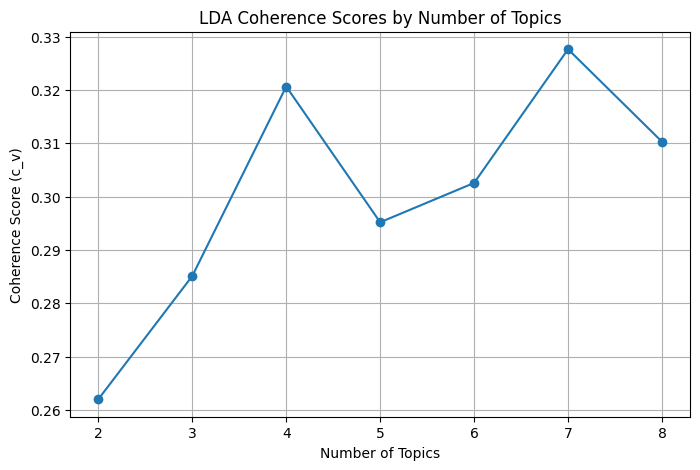

Best number of topics: 7
Best coherence score: 0.3277


In [125]:
topic_range = list(range(2, 9))

plt.figure(figsize=(8, 5))
plt.plot(topic_range, coherence_values, marker="o")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score (c_v)")
plt.title("LDA Coherence Scores by Number of Topics")
plt.xticks(topic_range)
plt.grid(True)
plt.show()

best_index = coherence_values.index(max(coherence_values))
best_num_topics = topic_range[best_index]

print("Best number of topics:", best_num_topics)
print("Best coherence score:", round(coherence_values[best_index], 4))

In [126]:
best_lda_model = model_list[best_index]

for i, topic in best_lda_model.print_topics(num_words=10):
    print(f"Topic {i}: {topic}")

Topic 0: 0.014*"studi" + 0.011*"work" + 0.010*"countri" + 0.009*"experi" + 0.008*"come" + 0.008*"live" + 0.008*"home" + 0.006*"abroad" + 0.006*"school" + 0.006*"friend"
Topic 1: 0.014*"studi" + 0.014*"school" + 0.014*"chines" + 0.014*"english" + 0.014*"abroad" + 0.009*"friend" + 0.009*"requir" + 0.009*"experi" + 0.008*"live" + 0.008*"life"
Topic 2: 0.016*"studi" + 0.012*"experi" + 0.011*"situat" + 0.009*"give" + 0.009*"offer" + 0.007*"countri" + 0.007*"sinc" + 0.007*"get" + 0.007*"thank" + 0.007*"appli"
Topic 3: 0.023*"work" + 0.009*"day" + 0.009*"sinc" + 0.009*"wast" + 0.009*"money" + 0.009*"home" + 0.009*"school" + 0.008*"friend" + 0.008*"life" + 0.007*"experi"
Topic 4: 0.030*"job" + 0.016*"experi" + 0.011*"appli" + 0.010*"work" + 0.009*"find" + 0.009*"graduat" + 0.008*"interview" + 0.007*"visa" + 0.007*"studi" + 0.007*"start"
Topic 5: 0.021*"chines" + 0.017*"experi" + 0.017*"studi" + 0.015*"abroad" + 0.012*"friend" + 0.009*"feel" + 0.009*"tri" + 0.008*"kinda" + 0.008*"everyon" + 0.0

In [127]:
dominant_topics = []

for bow in corpus:
    topic_probs = best_lda_model.get_document_topics(bow)
    dominant_topic = max(topic_probs, key=lambda x: x[1])[0]
    dominant_topics.append(dominant_topic)

processed_df["dominant_topic"] = dominant_topics

processed_df[["Text", "dominant_topic"]].head(10)

,Text,dominant_topic
0,International students in the U.S. – what’s yo...,4
1,Brutal truths international students learn the...,1
2,Life of an international student\n\nreddit -> ...,4
3,In what world are international students livin...,0
4,International Student Experience\n\nI’m an int...,2
5,Observations About Chinese International Stude...,6
6,Serious question: How are international studen...,1
7,Is the stereotype against International Studen...,4
8,Is Studying in Australia Still Worth It for In...,0
9,One of the consequences of the massive dominan...,1


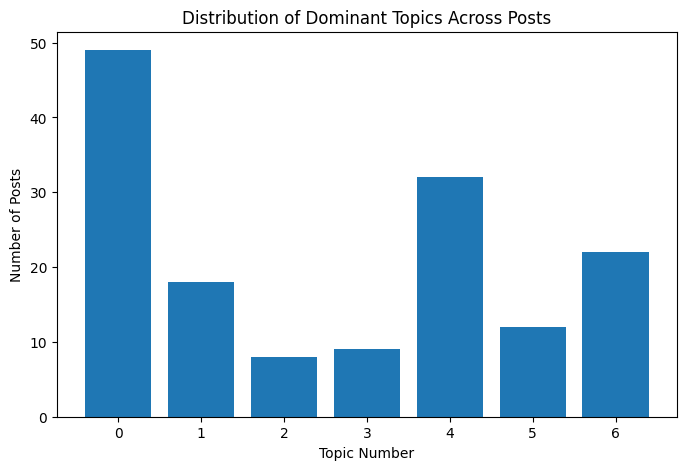

dominant_topic
0    49
1    18
2     8
3     9
4    32
5    12
6    22
Name: count, dtype: int64

In [128]:
topic_counts = processed_df["dominant_topic"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(topic_counts.index.astype(str), topic_counts.values)
plt.xlabel("Topic Number")
plt.ylabel("Number of Posts")
plt.title("Distribution of Dominant Topics Across Posts")
plt.show()

topic_counts

In [129]:
top_words_per_topic = {}

for topic_id in range(best_num_topics):
    words = best_lda_model.show_topic(topic_id, topn=10)
    top_words_per_topic[topic_id] = [word for word, prob in words]

top_words_per_topic

best_index = coherence_values.index(max(coherence_values))
best_num_topics = topic_range[best_index]
best_lda_model = model_list[best_index]

print("Best number of topics:", best_num_topics)
print("Best coherence score:", round(coherence_values[best_index], 4))

Best number of topics: 7
Best coherence score: 0.3277


# Comments
The coherence score was used to compare LDA models with different numbers of topics. The model with 7 topics produced the highest coherence score of 0.3277, so I selected it as the final LDA model. After reviewing the top words in each topic, I manually assigned topic labels based on the most meaningful word groups. Although some topics overlap, the model shows several recurring themes in the corpus, including international student experience, language and cultural adjustment, financial stress, career concerns, social belonging, and future planning.

## Topic 0:
study, work, country, experience, come, live, home, abroad, school, friend: General International Student Experience

## Topic 1:
study, school, chinese, english, abroad, friend, require, experience, live: Language, School, and Cultural Adjustment

## Topic 2:
study, experience, situation, give, offer, country, since, get, thank, apply: Advice and Personal Situations

## Topic 3:
work, day, since, waste, money, home, school, friend, life, experience: Financial Stress and Emotional Struggles

## Topic 4:
job, experience, apply, work, find, graduate, interview, visa, study, start: Jobs, Applications, and Work Authorization

## Topic 5:
chinese, experience, study, abroad, friend, feel, try, kinda, everyone, part: Social Belonging and Cultural Identity

## Topic 6:
look, university, uk, life, country, job, study, experience, want, find: University Choice and Future Planning

In [130]:
topic_labels = {
    0: "General International Student Experience",
    1: "Language, School, and Cultural Adjustment",
    2: "Advice and Personal Situations",
    3: "Financial Stress and Emotional Struggles",
    4: "Jobs, Applications, and Work Authorization",
    5: "Social Belonging and Cultural Identity",
    6: "University Choice and Future Planning"
}

topic_summary = []

for topic_num, topic_words in best_lda_model.print_topics(num_words=10):
    topic_summary.append({
        "Topic Number": topic_num,
        "Top Words": topic_words,
        "Interpretation": topic_labels[topic_num]
    })

topic_summary_df = pd.DataFrame(topic_summary)
topic_summary_df

,Topic Number,Top Words,Interpretation
0,0,"0.014*""studi"" + 0.011*""work"" + 0.010*""countri""...",General International Student Experience
1,1,"0.014*""studi"" + 0.014*""school"" + 0.014*""chines...","Language, School, and Cultural Adjustment"
2,2,"0.016*""studi"" + 0.012*""experi"" + 0.011*""situat...",Advice and Personal Situations
3,3,"0.023*""work"" + 0.009*""day"" + 0.009*""sinc"" + 0....",Financial Stress and Emotional Struggles
4,4,"0.030*""job"" + 0.016*""experi"" + 0.011*""appli"" +...","Jobs, Applications, and Work Authorization"
5,5,"0.021*""chines"" + 0.017*""experi"" + 0.017*""studi...",Social Belonging and Cultural Identity
6,6,"0.014*""look"" + 0.013*""univers"" + 0.010*""uk"" + ...",University Choice and Future Planning


# B. BERT for Text Analysis
- Use a pre-trained BERT model (e.g., bert-base-uncased) to:

         - Extract embeddings for your documents.
         - Perform topic classification.

  
- Visualize or interpret the results (e.g., t-SNE plots, clustering, or attention maps).


In [135]:
import torch
import numpy as np
from transformers import BertTokenizer, BertModel
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

/Users/admin/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [136]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert_model = BertModel.from_pretrained("bert-base-uncased")

bert_model.eval()

Loading weights: 100%|█████████████████████| 199/199 [00:00<00:00, 11974.96it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [137]:
documents = processed_df["Text"].dropna().astype(str).tolist()

len(documents)

150

In [138]:
def get_bert_embedding(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    )
    
    with torch.no_grad():
        outputs = bert_model(**inputs)
    
    # Use the [CLS] token embedding as the document embedding
    cls_embedding = outputs.last_hidden_state[:, 0, :]
    
    return cls_embedding.squeeze().numpy()

In [139]:
bert_embeddings = []

for doc in documents:
    embedding = get_bert_embedding(doc)
    bert_embeddings.append(embedding)

bert_embeddings = np.array(bert_embeddings)

bert_embeddings.shape

(150, 768)

In [140]:
num_clusters = 7

kmeans = KMeans(
    n_clusters=num_clusters,
    random_state=42,
    n_init=10
)

bert_clusters = kmeans.fit_predict(bert_embeddings)

processed_df["bert_cluster"] = bert_clusters

processed_df[["Text", "bert_cluster"]].head()

,Text,bert_cluster
0,International students in the U.S. – what’s yo...,5
1,Brutal truths international students learn the...,0
2,Life of an international student\n\nreddit -> ...,0
3,In what world are international students livin...,6
4,International Student Experience\n\nI’m an int...,0


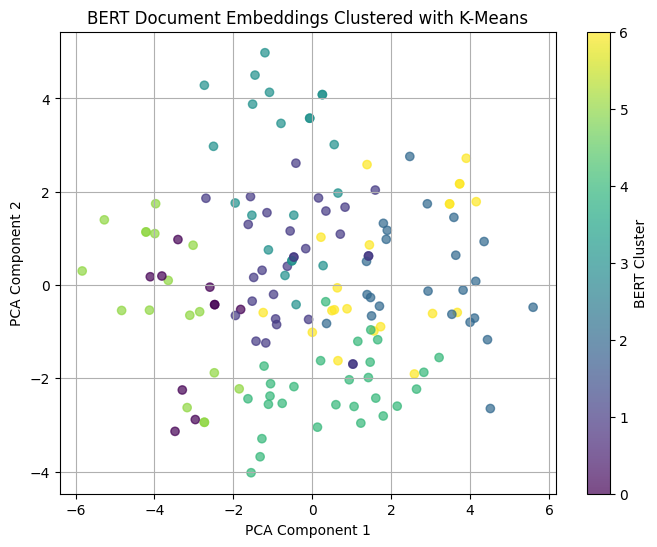

In [141]:
pca = PCA(n_components=2, random_state=42)
bert_2d = pca.fit_transform(bert_embeddings)

plt.figure(figsize=(8, 6))
plt.scatter(
    bert_2d[:, 0],
    bert_2d[:, 1],
    c=bert_clusters,
    alpha=0.7
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("BERT Document Embeddings Clustered with K-Means")
plt.colorbar(label="BERT Cluster")
plt.grid(True)
plt.show()

In [142]:
for cluster_num in range(num_clusters):
    print(f"\nBERT Cluster {cluster_num}")
    print("-" * 50)
    
    sample_posts = processed_df[processed_df["bert_cluster"] == cluster_num]["Text"].head(3)
    
    for post in sample_posts:
        print(post[:300])
        print()


BERT Cluster 0
--------------------------------------------------
Brutal truths international students learn the hard way

Networking is more important than GPA
First job rarely matches your degree
Savings disappear faster than you think
Winter depression is REAL
The loneliness hits randomly
But the personal growth is unbelievable

Life of an international student

reddit -> email -> portal

repeat

International Student Experience

I’m an international student who has been studying here in NL for 4 years now. I find that the experience can be very isolating, particularly if you’re unlucky enough to face any financial or mental health challenges that set you apart from the average student. I wo


BERT Cluster 1
--------------------------------------------------
Observations About Chinese International Students

I’m currently attending university in the U.S. and graduating soon. I wanted to share an observation and get some feedback to see whether others have experienced something simi

In [152]:
bert_cluster_labels = {
    0: "General Challenges and Personal Growth",
    1: "Stereotypes, Language, and Cultural Perceptions",
    2: "Immigration, Work, and Financial Pressure",
    3: "Country-Specific Study Abroad Experiences",
    4: "Negative Experiences and Campus Frustrations",
    5: "Studying Abroad Decisions and Daily Management",
    6: "Student Status and Career Concerns"
}

processed_df["bert_cluster_label"] = processed_df["bert_cluster"].map(bert_cluster_labels)

processed_df[["Text", "bert_cluster", "bert_cluster_label"]].head(10)

,Text,bert_cluster,bert_cluster_label
0,International students in the U.S. – what’s yo...,5,Studying Abroad Decisions and Daily Management
1,Brutal truths international students learn the...,0,General Challenges and Personal Growth
2,Life of an international student\n\nreddit -> ...,0,General Challenges and Personal Growth
3,In what world are international students livin...,6,Student Status and Career Concerns
4,International Student Experience\n\nI’m an int...,0,General Challenges and Personal Growth
5,Observations About Chinese International Stude...,1,"Stereotypes, Language, and Cultural Perceptions"
6,Serious question: How are international studen...,1,"Stereotypes, Language, and Cultural Perceptions"
7,Is the stereotype against International Studen...,1,"Stereotypes, Language, and Cultural Perceptions"
8,Is Studying in Australia Still Worth It for In...,5,Studying Abroad Decisions and Daily Management
9,One of the consequences of the massive dominan...,6,Student Status and Career Concerns


In [153]:
cluster_counts = processed_df["bert_cluster_label"].value_counts()

cluster_counts

bert_cluster_label
Stereotypes, Language, and Cultural Perceptions    29
Negative Experiences and Campus Frustrations       28
Immigration, Work, and Financial Pressure          23
Country-Specific Study Abroad Experiences          22
Student Status and Career Concerns                 21
Studying Abroad Decisions and Daily Management     17
General Challenges and Personal Growth             10
Name: count, dtype: int64

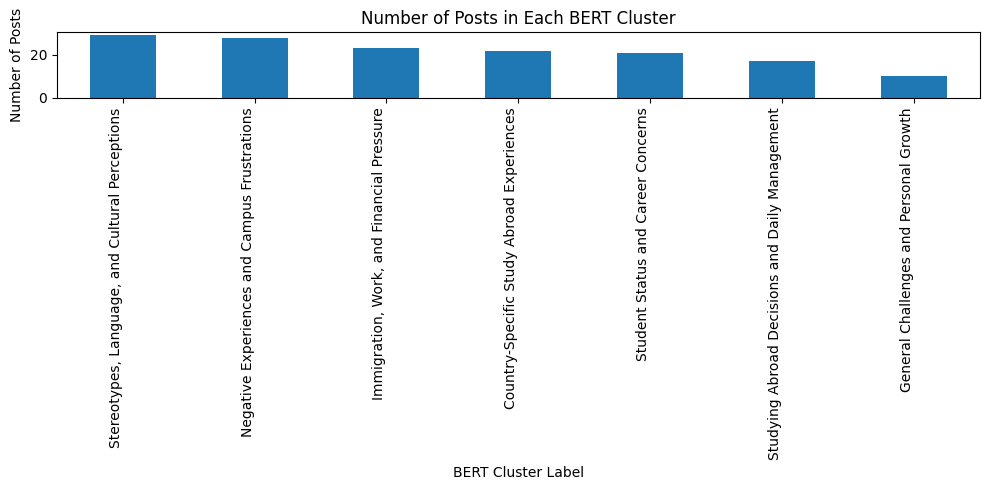

In [154]:
plt.figure(figsize=(10, 5))
cluster_counts.plot(kind="bar")

plt.xlabel("BERT Cluster Label")
plt.ylabel("Number of Posts")
plt.title("Number of Posts in Each BERT Cluster")
plt.xticks(ha="right")
plt.tight_layout()
plt.show()

The BERT model transformed each Reddit post into a 768-dimensional embedding. These embeddings were then clustered using K-Means with 7 clusters, matching the number of topics selected in the LDA section. The PCA visualization shows how the documents are grouped based on semantic similarity. Unlike LDA, which focuses on repeated words, BERT considers the broader meaning and context of the posts.

After reviewing sample posts from each cluster, I assigned descriptive labels to the BERT clusters. The clusters showed themes such as academic life, career concerns, financial stress, social belonging, and future planning. Some overlap between clusters is expected because international student experiences often combine multiple issues, such as school, work, money, and immigration.

## Conclusion

This project applied two NLP techniques to a corpus of 150 Reddit posts about international student experiences. LDA produced 7 interpretable topics with a best coherence score of **0.3277**, surfacing themes such as financial stress, career/visa concerns, cultural adjustment, and social belonging. BERT embeddings clustered into 7 groups that captured similar themes but with more contextual nuance — posts discussing both immigration stress and career anxiety were grouped together rather than split, which reflects how interconnected these concerns actually are.

**LDA vs. BERT:** LDA was easier to interpret because top keywords directly label each topic. BERT required manual review of sample posts per cluster, but produced more semantically coherent groupings. For the goal of identifying themes to inform student support services, LDA is more actionable, while BERT would be more appropriate for a downstream task like classifying new posts.

**Limitations:** The corpus is relatively small (150 posts). A larger, balanced dataset from multiple subreddits would likely yield cleaner topic separation and higher coherence scores. Some Reddit-specific noise (informal language, memes, inside references) also affected preprocessing quality despite the extended stopword list.

**References:**
- Reddit corpus collected from r/internationalstudents *(update with exact source/URL or Kaggle link)*.
- Řehůřek, R., & Sojka, P. (2010). Software Framework for Topic Modelling with Large Corpora. *LREC 2010 Workshop*. https://radimrehurek.com/gensim/
- Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding. *NAACL-HLT 2019*. https://arxiv.org/abs/1810.04805
- Bird, S., Klein, E., & Loper, E. (2009). *Natural Language Processing with Python*. O'Reilly. (NLTK/PorterStemmer)
- Honnibal, M., & Montani, I. (2017). spaCy 2: Natural language understanding with Bloom embeddings, convolutional neural networks and incremental parsing. https://spacy.io